# ROC & AUC

For documents, check: https://smilingwayne.github.io/me/ML/StatLearnMethod/AUC/

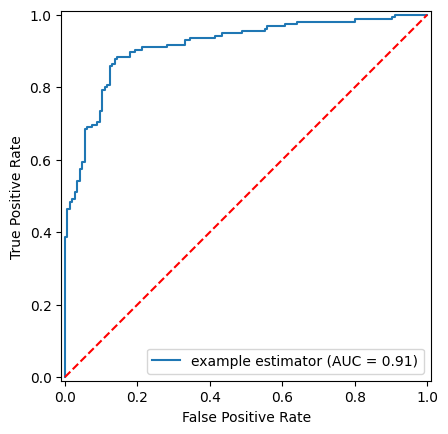

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = LogisticRegression()  # Logistics Regression Classifier
clf.fit(X_train, y_train)   # X_train and y_train for training
y_score = clf.predict_proba(X_test)[:, 1]  # Predict on x_test
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc_score = roc_auc_score(y_test, y_score)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score,
                                  estimator_name='example estimator')
display.plot()
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random Classifier')  
plt.show()


In [23]:
# manual check :

def manual_tpr_fpr(y_true, y_pred_prob, threshold):

    y_pred = np.where(y_pred_prob >= threshold, 1, 0)
    
    # Get TP, FP, TN, FN
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    
    # Get TPR, FPR ... 
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    
    return tpr, fpr

if __name__ == "__main__":
    threshold_np = sorted(y_score.tolist(), reverse = True)
    y_true = y_test
    auc_score_manual = 0
    prev_tpr = 0; prev_fpr = 0
    for idx, threshold in enumerate(threshold_np):
        tpr, fpr = manual_tpr_fpr(y_true, y_score, threshold)
        # print(round(threshold,6), round(tpr, 6), round(fpr, 6))
        if idx > 0:
            auc_score_manual += (fpr - prev_fpr) * (tpr + prev_tpr) / 2
        prev_tpr, prev_fpr = tpr, fpr 
    print(f"Manual Check AUC: {auc_score_manual}")
    # Is the same as above!

Manual Check AUC: 0.9141713014460501


# PR-Curve

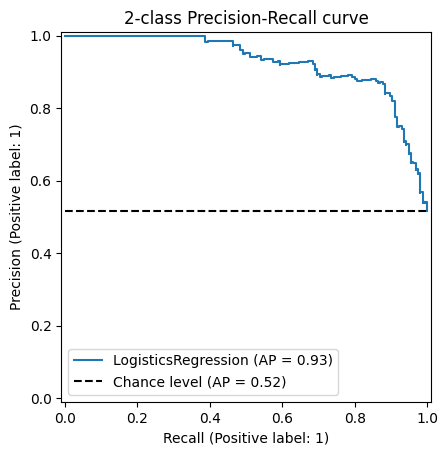

In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
precisions, recalls, thresholds = precision_recall_curve(y_test, y_score)

display = PrecisionRecallDisplay.from_estimator(
    clf, X_test, y_test, name="LogisticsRegression", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_test, y_score)
print(f"AP = {ap:.6f}")  
ap_maunal = 0
for i, precision in enumerate(precisions):
    if i > 0:
        ap_maunal += abs(- recalls[i] + recalls[i - 1]) * precision
print(f"Maunal Check: {ap_maunal}")

# Explanation:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html
# ...(Average Precision) is different from computing the area under the precision-recall curve with the trapezoidal rule, 
# which uses linear interpolation and can be too optimistic.

AP = 0.927529
Maunal Check: 0.9270423230228559
